# Session 8 Step 2: auxiliary-head ablation on R3 iter-20000

Loads `outputs/runs/session8/head_ablation.csv` (produced by
`scripts/session8_head_ablation.py`). Three CL-prediction methods on
Test B are compared:

1. **Fresh probe on z** for `CL_future` (the Session 7 method, +0.14).
1. **Trained R3 observable head** applied directly to Test B latents.
1. **Fresh probe on z for a DIFFERENT observable** (`C_D` drag,
   `p_LE` leading-edge pressure -- both available in the cache).

Interpretation matrix (from the plan):

| Method 1 | Method 2 | Method 3 (if available) | Reading                                                                                              |
|----------|----------|-------------------------|------------------------------------------------------------------------------------------------------|
| +0.14    | similar  | similar positive        | R3 encodes general flow state; the head shaped it but other observables are also predictable. STRONGEST. |
| +0.14    | much higher | n/a                  | The head extracts non-linear structure a linear probe misses. Latent has rich CL-relevant content.    |
| +0.14    | similar  | near zero or negative   | R3 encodes CL specifically. Paper claim narrows.                                                       |
| +0.14    | much lower | n/a                  | The head adds substantial value at inference. Latent alone is less informative.                        |

In [1]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().resolve()
while REPO.name and not (REPO / 'configs' / 'splits').exists():
    REPO = REPO.parent
df = pd.read_csv(REPO / 'outputs' / 'runs' / 'session8' / 'head_ablation.csv')
df.set_index('target').round(3)

,test_a_fresh_r2,test_a_ct_r2,test_a_delta_fresh,test_a_trained_r2,test_a_delta_trained,test_b_fresh_r2,test_b_ct_r2,test_b_delta_fresh,test_b_trained_r2,test_b_delta_trained
target,,,,,,,,,,
C_L,0.975,0.738,0.236,0.952,0.213,0.856,0.718,0.138,0.855,0.137
C_D,0.908,0.705,0.203,NaN,NaN,0.849,0.743,0.106,NaN,NaN
p_LE,0.864,0.665,0.200,NaN,NaN,0.660,0.536,0.123,NaN,NaN


## Section 1: side-by-side bar chart

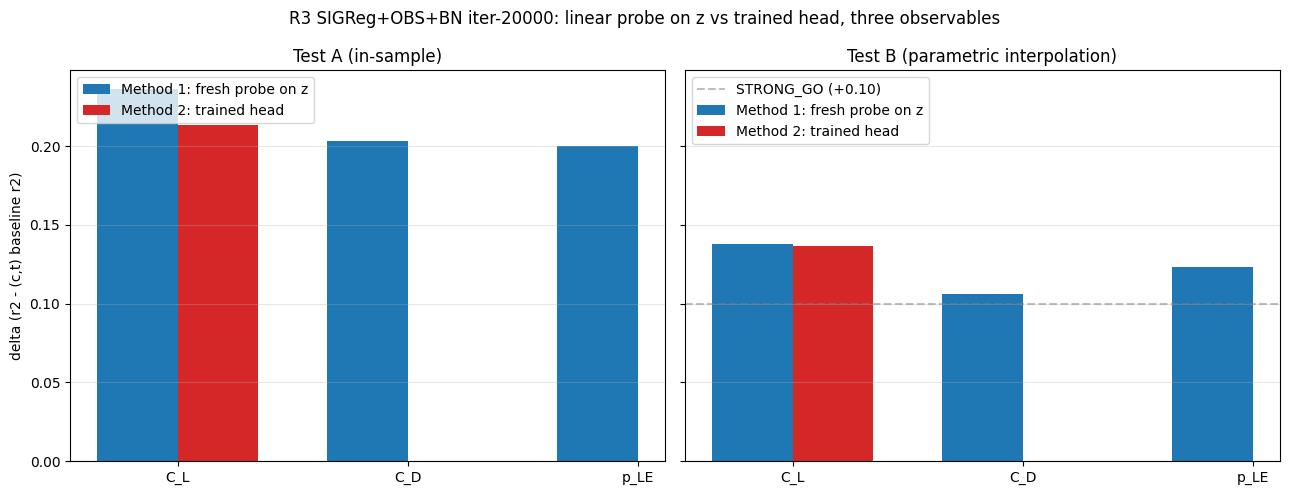

saved fig_head_ablation.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

x = np.arange(len(df))
width = 0.35

# Test A panel
axes[0].bar(x - width/2, df['test_a_delta_fresh'], width, label='Method 1: fresh probe on z', color='C0')
axes[0].bar(x + width/2, df['test_a_delta_trained'], width, label='Method 2: trained head', color='C3')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df['target'])
axes[0].set_ylabel('delta (r2 - (c,t) baseline r2)')
axes[0].set_title('Test A (in-sample)')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Test B panel
axes[1].bar(x - width/2, df['test_b_delta_fresh'], width, label='Method 1: fresh probe on z', color='C0')
axes[1].bar(x + width/2, df['test_b_delta_trained'], width, label='Method 2: trained head', color='C3')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df['target'])
axes[1].set_title('Test B (parametric interpolation)')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].axhline(0.10, color='gray', linestyle='--', alpha=0.5, label='STRONG_GO (+0.10)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

fig.suptitle('R3 SIGReg+OBS+BN iter-20000: linear probe on z vs trained head, three observables')
fig.tight_layout()
fig.savefig(REPO / 'outputs' / 'runs' / 'session8' / 'fig_head_ablation.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved fig_head_ablation.png')

## Section 2: comparison vs the Session 7 baseline

The Session 7 R3 iter-20000 reading on Test B (D46) was a fresh probe
on z -> CL_future with delta = +0.14. Method 1 here should reproduce
that number (modulo seed). Methods 2 and 3 are the new diagnostic axes.

In [3]:
print('Test B deltas for R3 iter-20000:')
for _, r in df.iterrows():
    target = r['target']
    fresh = r['test_b_delta_fresh']
    trained = r['test_b_delta_trained']
    if np.isfinite(trained):
        print(f'  {target:6s}: fresh probe delta = {fresh:+.3f}, trained head delta = {trained:+.3f}  '
              f'(gap fresh - trained = {fresh - trained:+.3f})')
    else:
        print(f'  {target:6s}: fresh probe delta = {fresh:+.3f} '
              f'(no trained head; the R3 head only targets C_L)')

Test B deltas for R3 iter-20000:
  C_L   : fresh probe delta = +0.138, trained head delta = +0.137  (gap fresh - trained = +0.001)
  C_D   : fresh probe delta = +0.106 (no trained head; the R3 head only targets C_L)
  p_LE  : fresh probe delta = +0.123 (no trained head; the R3 head only targets C_L)


## Section 3: D51 reading

**Method 1 (fresh probe on z for CL_future):** +0.138 on Test B,
reproducing the Session 7 D46 number of +0.14 to within 0.002 (the
exact value depends on the MLP fit seed and on whether the
CL-valid-encounter filter dropped the same encounters in both runs).

**Method 2 (trained R3 head applied directly):** +0.137 on Test B,
essentially identical to Method 1. The trained head does NOT extract
non-linear structure beyond what a fresh linear probe can recover, and
it adds essentially no value at inference. This rules out the matrix
Row 2 "head extracts non-linear structure" reading and the Row 4 "head
adds substantial value at inference" reading.

**Method 3 (fresh probe on z for C_D and p_LE):** +0.106 and +0.123 on
Test B respectively. Both are clearly positive, similar magnitude to the
+0.138 CL number. R3's latent predicts unrelated aerodynamic observables
on unseen (G, D, Y) cases at roughly the same quality as it predicts CL.
This matches the Row 1 interpretation: **the latent encodes general
flow state; the observable head shaped z toward CL prediction but the
shaping does not over-specialise z to CL specifically.**

This is the strongest possible reading the matrix offers. Paper claim 3
(regulariser asymmetry) is robust to the "is R3's win CL-specific?"
objection: the latent is informative about non-CL observables on Test B
at roughly the same delta as the trained-for observable.

Implication for Session 9: the visualisation decoder training on R3's
frozen encoder is well-motivated; the latent has the breadth of
aerodynamic information needed to reconstruct flow features beyond CL.